In [1]:
import numpy as np
import matplotlib.pyplot as plt
from model.repressilator import Repressilator
from model.pid import PID
from analysis.signal_analysis import *
from visualization.plotter import *
import tqdm
from scipy.optimize import fsolve

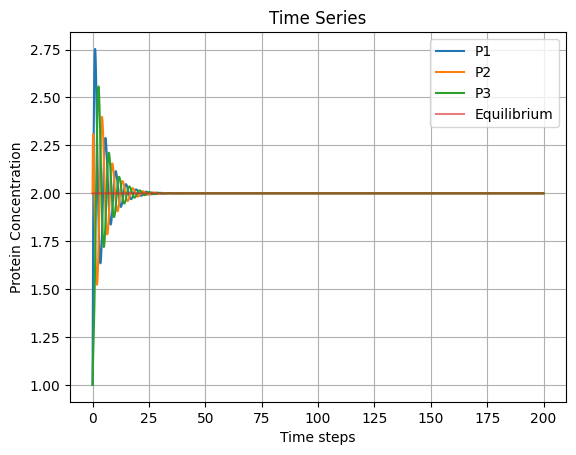

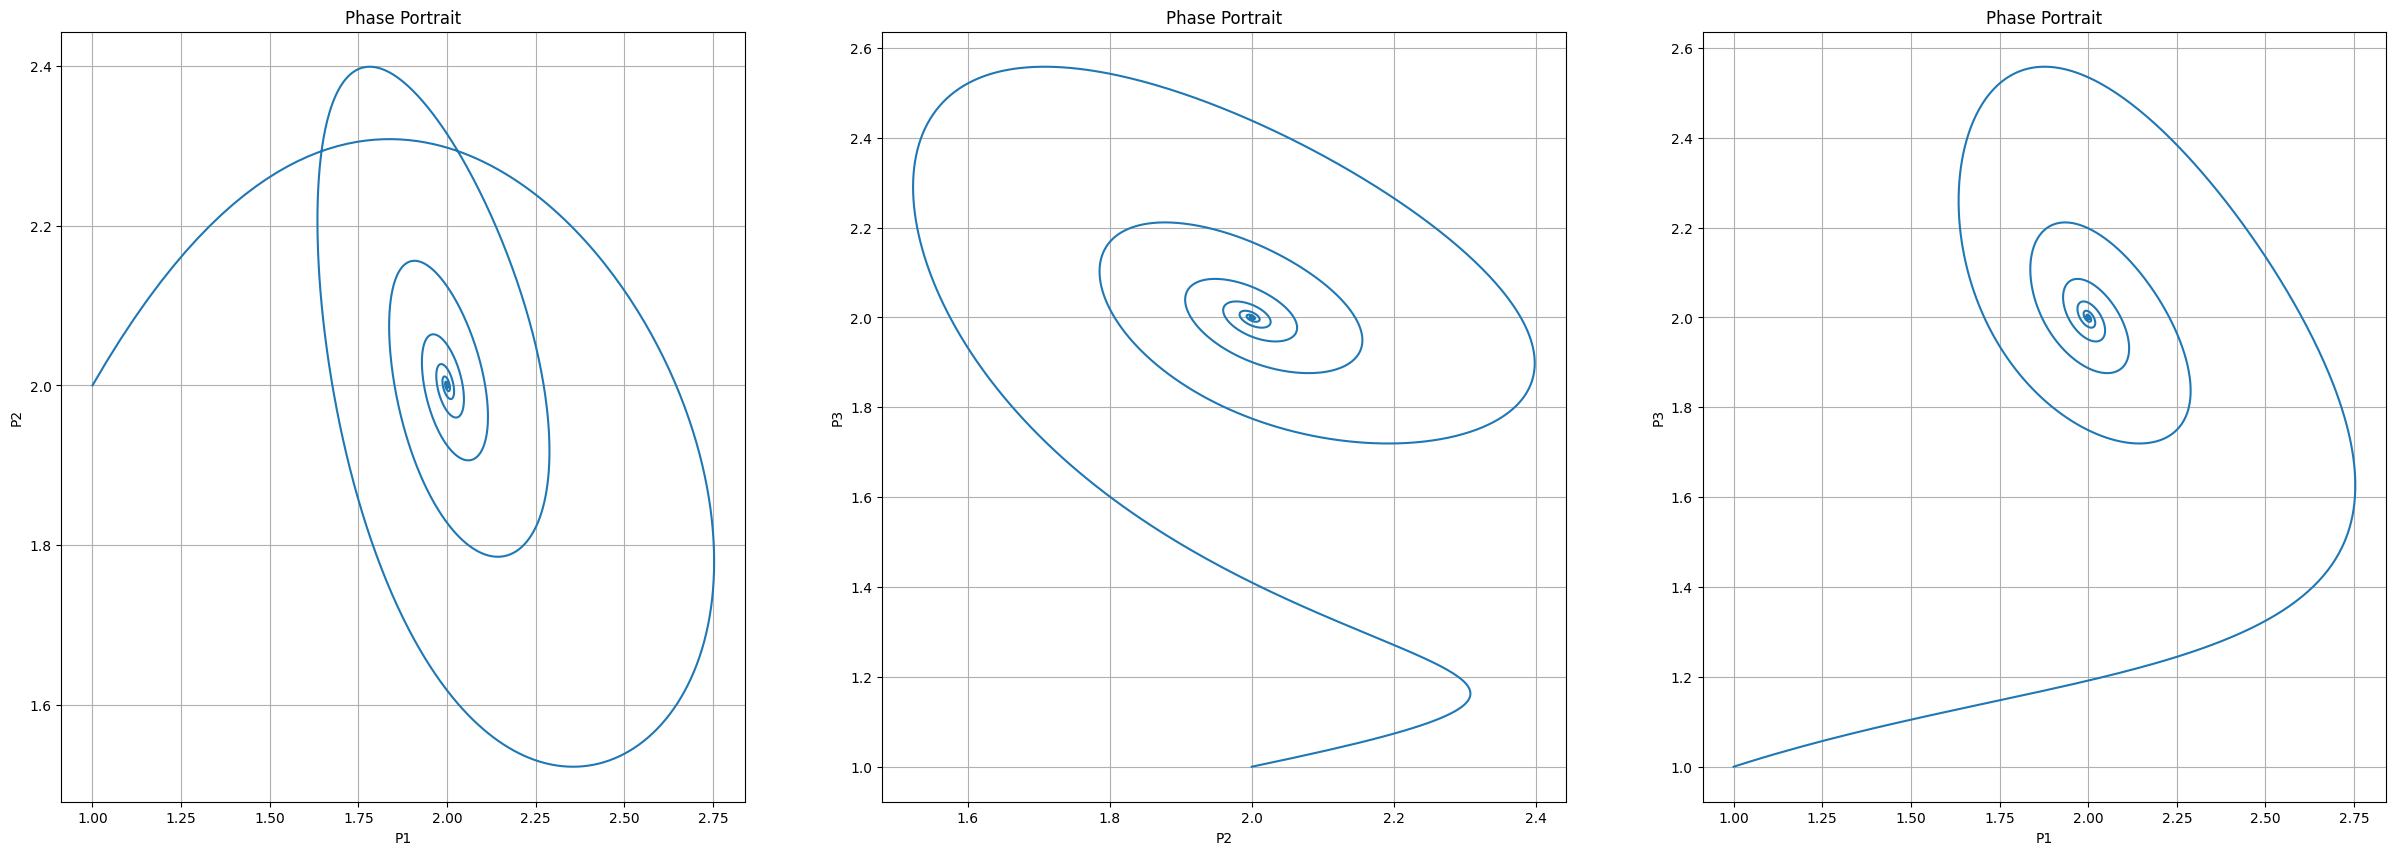

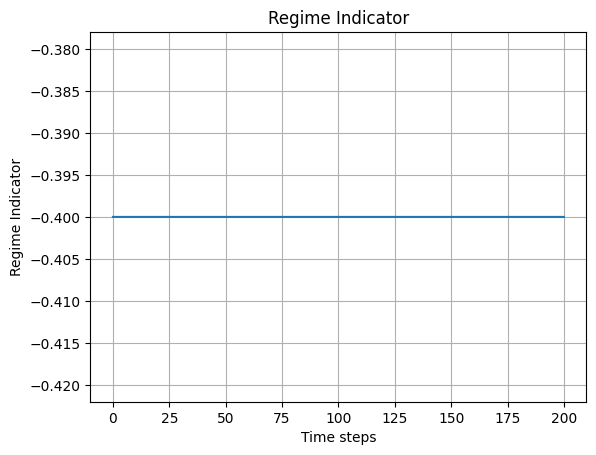

In [2]:
model = Repressilator()
initial_state = np.array([1, 2, 1])
t, state, u, r, p_eq = model.simulate(initial_state)
time_series(t, state, p_eq)
phase_portrait(state)
regime_indicator(t, r)

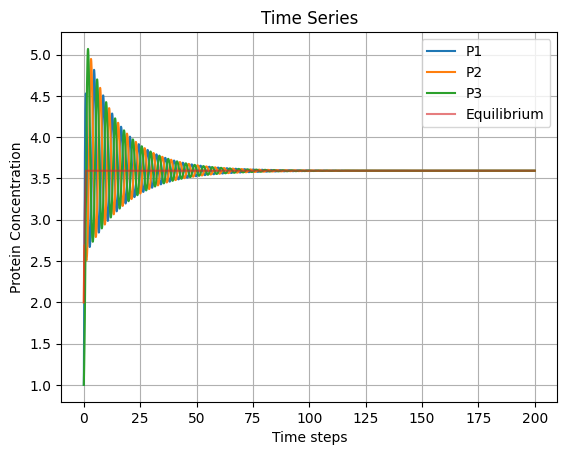

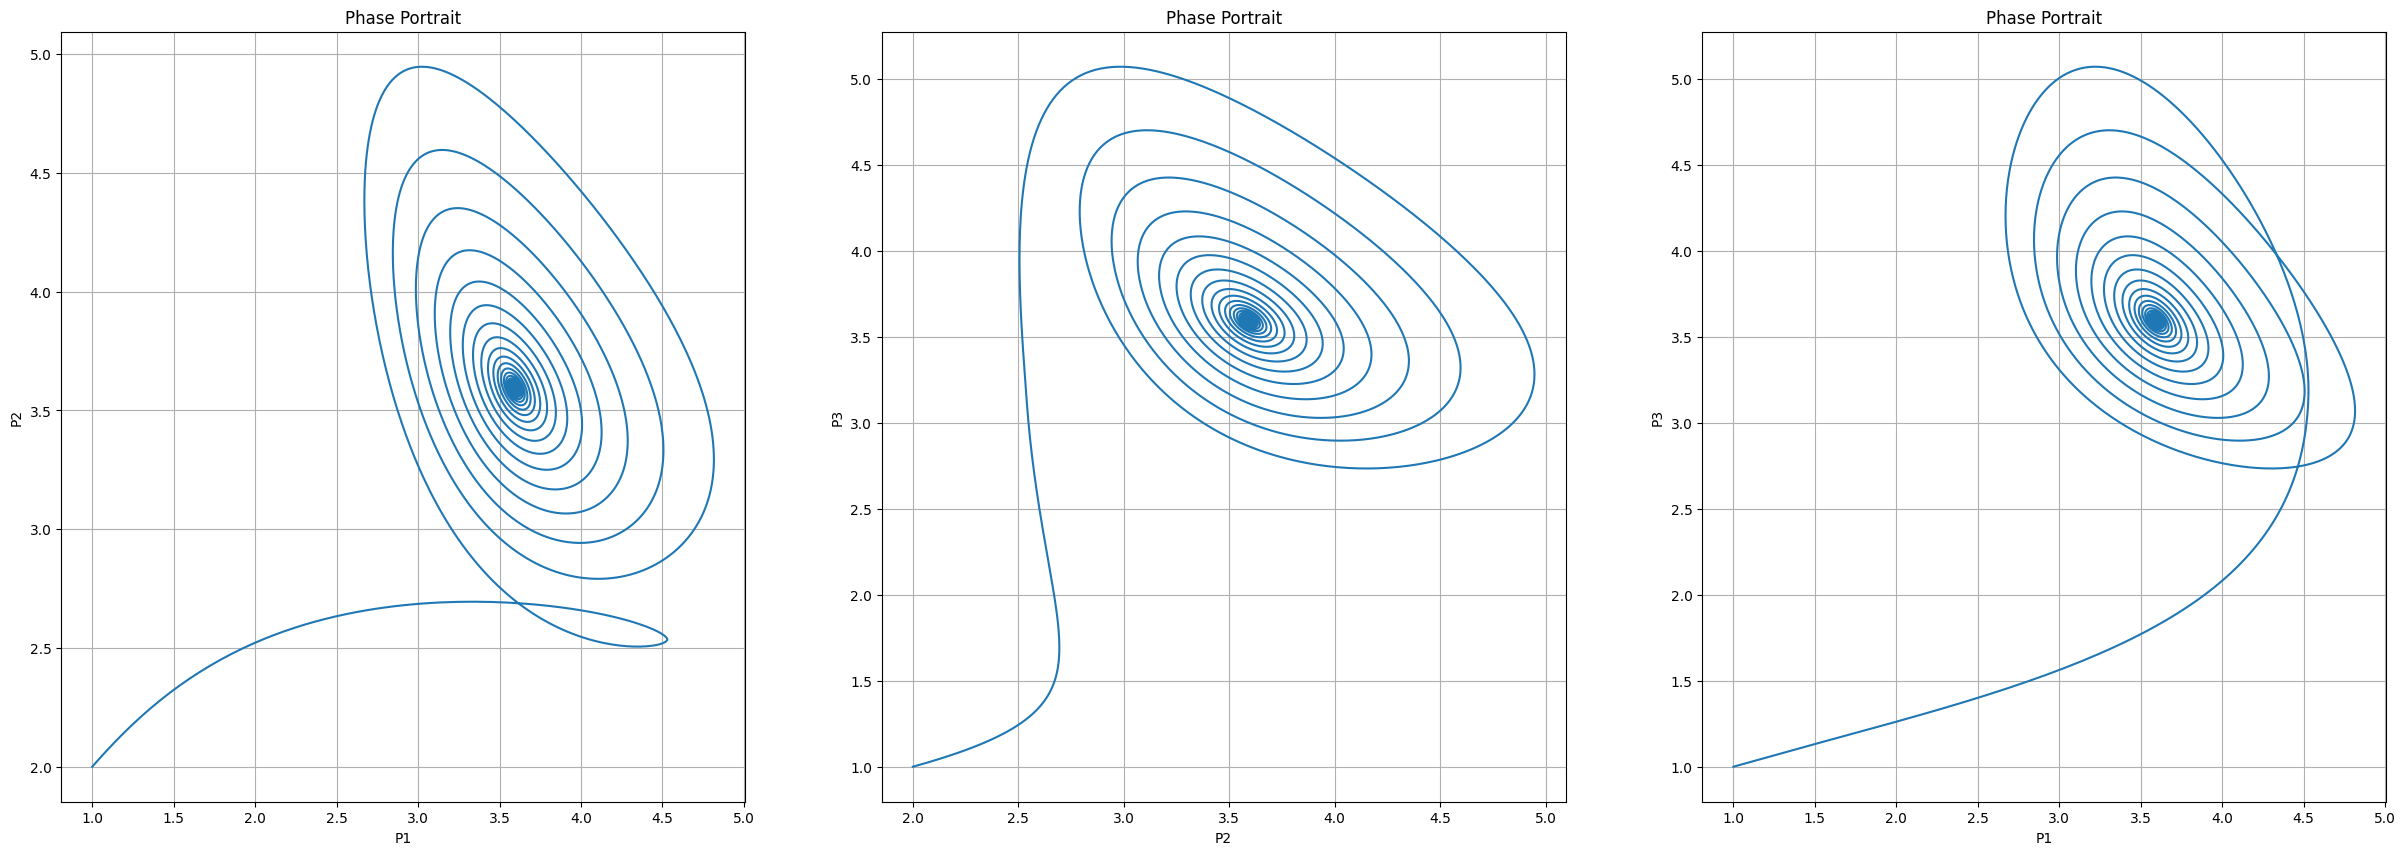

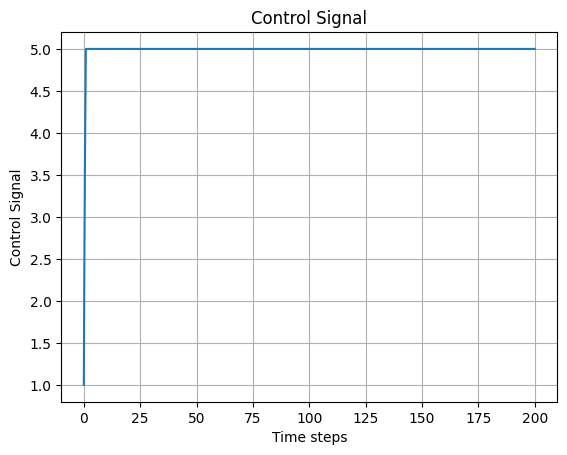

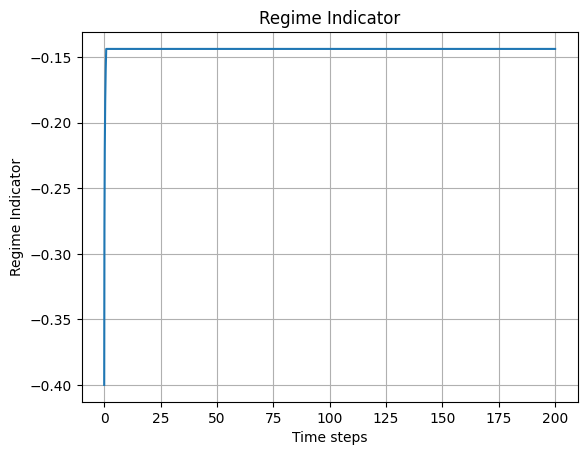

In [3]:
controller = PID(kp = 0.2, ki = 0, kd = 0, target_regime = 0.02)
model = Repressilator()

t, state, u, r, p_eq = model.simulate(initial_state, control = controller, u0 = 1)
time_series(t, state, p_eq)
phase_portrait(state)
control_signal(t, u)
regime_indicator(t, r)

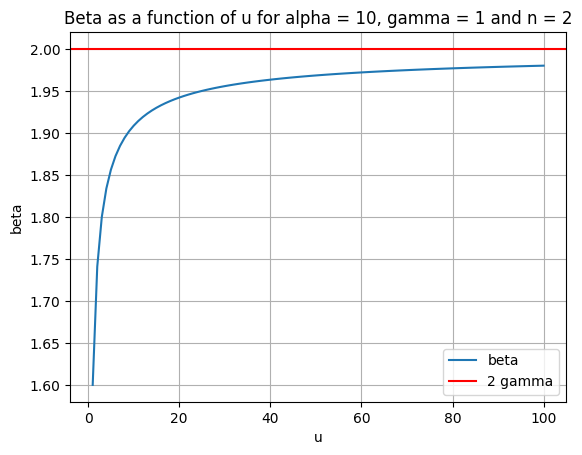

In [17]:
u_values = np.linspace(1, 100, 100)
beta = np.zeros(100)
for u in u_values:
    model = Repressilator(alpha = 10, gamma = 1, n = 2)
    beta[u_values == u] = model.beta(u)
plt.plot(u_values, beta, label = 'beta')
plt.xlabel("u")
plt.ylabel("beta")
plt.grid()
plt.axhline(2 * model.gamma, color = 'red', label = '2 gamma')
plt.title('Beta as a function of u for alpha = 10, gamma = 1 and n = 2')
plt.legend()
plt.show()

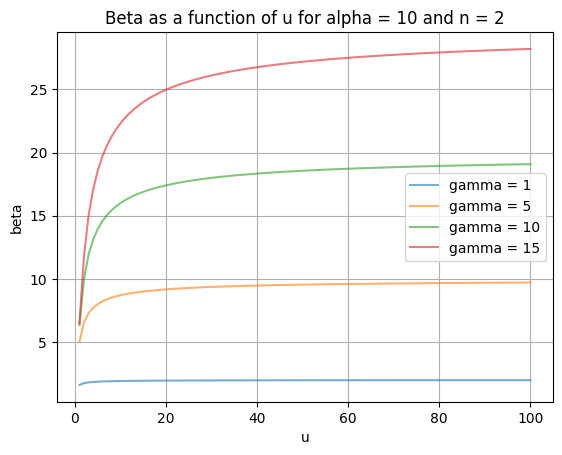

In [5]:
beta = np.zeros(100)
gamma_values = np.array([1, 5, 10, 15])
for gamma in gamma_values:
    u_values = np.linspace(1, 100, 100)
    for u in u_values:
        model = Repressilator(alpha = 10, gamma = gamma, n = 2)
        beta[u_values == u] = model.beta(u)
    plt.plot(u_values, beta, label = f'gamma = {gamma}', alpha = 0.6)
plt.xlabel("u")
plt.ylabel("beta")
plt.grid()
plt.title('Beta as a function of u for alpha = 10 and n = 2')
plt.legend()
plt.show()

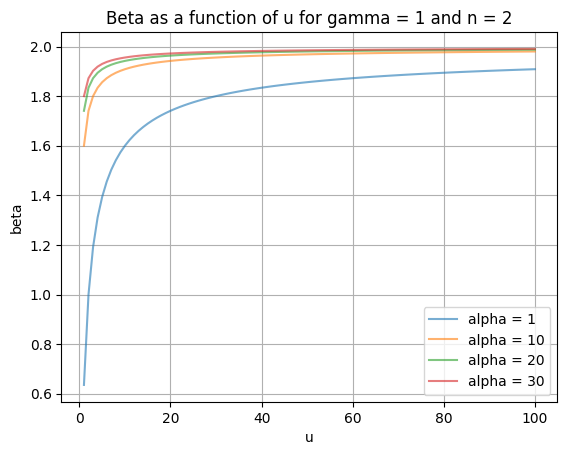

In [6]:
beta = np.zeros(100)
alpha_values = np.array([1, 10, 20, 30])
for alpha in alpha_values:
    u_values = np.linspace(1, 100, 100)
    for u in u_values:
        model = Repressilator(alpha = alpha, gamma = 1, n = 2)
        beta[u_values == u] = model.beta(u)
    plt.plot(u_values, beta, label = f'alpha = {alpha}', alpha = 0.6)
plt.xlabel("u")
plt.ylabel("beta")
plt.grid()
plt.title('Beta as a function of u for gamma = 1 and n = 2')
plt.legend()
plt.show()

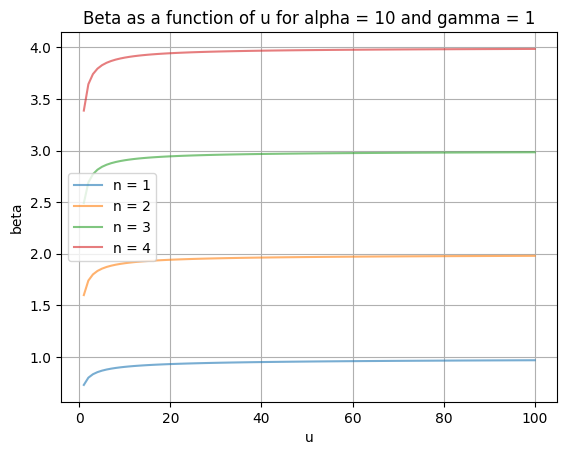

In [7]:
beta = np.zeros(100)
n_values = np.array([1, 2, 3, 4])
for n in n_values:
    u_values = np.linspace(1, 100, 100)
    for u in u_values:
        model = Repressilator(alpha = 10, gamma = 1, n = n)
        beta[u_values == u] = model.beta(u)
    plt.plot(u_values, beta, label = f'n = {n}', alpha = 0.6)
plt.xlabel("u")
plt.ylabel("beta")
plt.grid()
plt.title('Beta as a function of u for alpha = 10 and gamma = 1')
plt.legend()
plt.show()

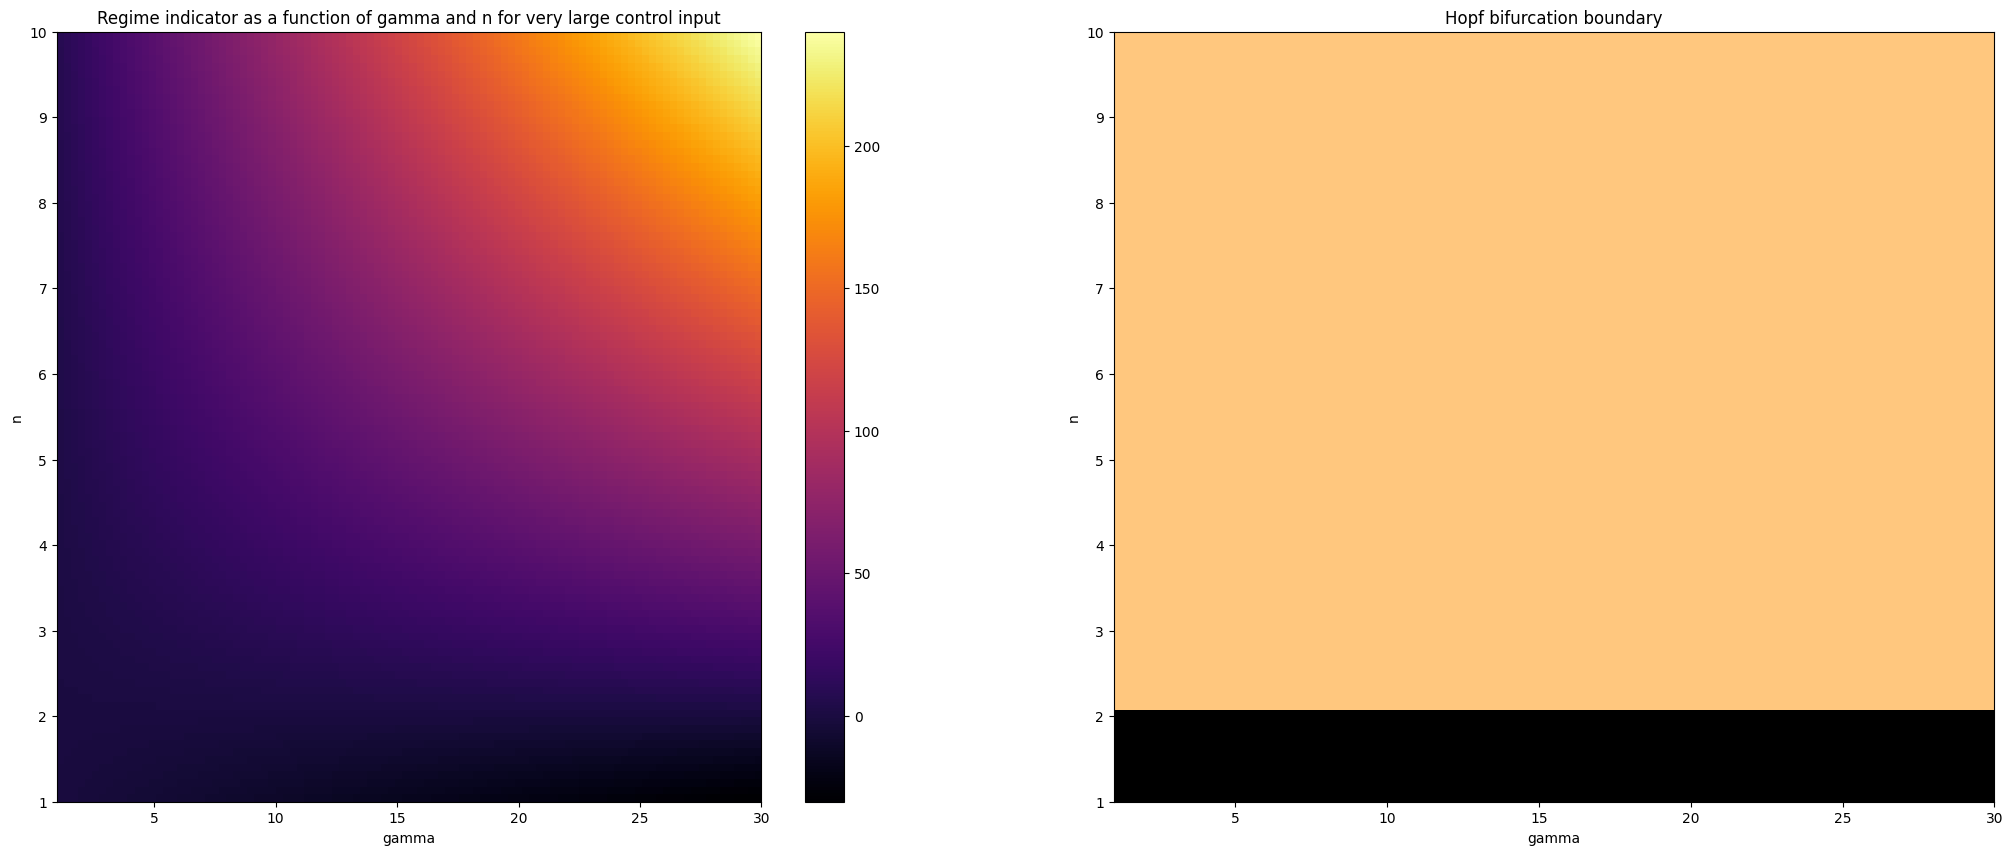

In [8]:
gamma_values = np.linspace(1, 30, 100)
n_values = np.linspace(1, 10, 100)
r = np.zeros((100,100))
u = 100000
for gamma in gamma_values:
    for n in n_values:
        model = Repressilator(alpha = 10, gamma = gamma, n = n)
        r[n_values == n, gamma_values == gamma] = model.beta(u) - 2 * gamma

r_mask = np.zeros((100,100))
r_mask[r == 0] = 1
r_mask[r > 0] = 2
plt.figure(figsize = (25, 10))
plt.subplot(1,2,1)
plt.imshow(r, extent = [1, 30, 1, 10], aspect = 'auto', cmap = 'inferno', origin = 'lower')
plt.xlabel("gamma")
plt.ylabel("n")
plt.colorbar()
plt.title('Regime indicator as a function of gamma and n for very large control input')
plt.subplot(1,2,2)
plt.imshow(r_mask, extent = [1, 30, 1, 10], aspect = 'auto', cmap = 'copper', origin = 'lower')
plt.xlabel("gamma")
plt.ylabel("n")
plt.title('Hopf bifurcation boundary')
plt.show()

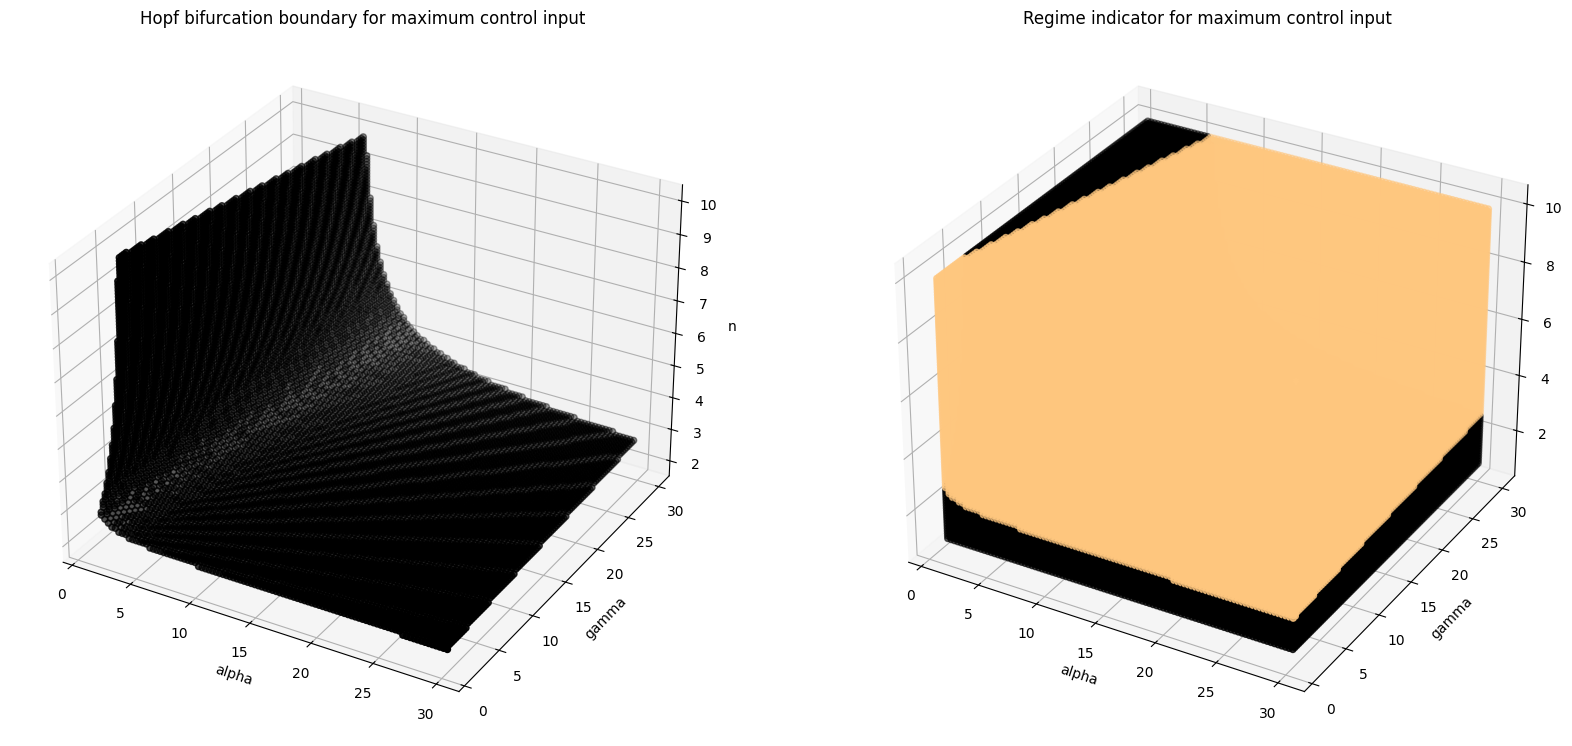

In [9]:
gamma_values = np.linspace(1, 30, 100)
n_values = np.linspace(1, 10, 100)
alpha_values = np.linspace(1, 30, 100)
r = np.zeros((100,100,100))
u = 5
for i, gamma in enumerate(gamma_values):
    for k, n in enumerate(n_values):
        for j, alpha in enumerate(alpha_values):
            model = Repressilator(alpha = alpha, gamma = gamma, n = n)
            r[j,i,k] = model.beta(u) - 2 * gamma

r_mask = np.zeros((100,100,100))
r_mask[r > 0] = 1
surface = np.zeros((100,100,100), dtype = bool)

for i in range(1,99):
    for j in range(1,99):
        for k in range(1,99):
            if r_mask[i,j,k] == 1:
                surface[i,j,k] = 1 - r_mask[i-1,j,k] * r_mask[i+1,j,k] * r_mask[i,j-1,k] * r_mask[i,j+1,k] * r_mask[i,j,k-1] * r_mask[i,j,k+1]



fig = plt.figure(figsize = (20, 10))
ax = fig.add_subplot(1,2,1, projection='3d')
X,Y ,Z = np.meshgrid(alpha_values, gamma_values, n_values, indexing = 'ij')
ax.scatter(X[surface], Y[surface], Z[surface], color = 'black')
ax.set_xlabel('alpha')
ax.set_ylabel('gamma')
ax.set_zlabel('n')
ax.set_title('Hopf bifurcation boundary for maximum control input')

ax2 = fig.add_subplot(1,2,2, projection='3d')
ax2.scatter(X,Y,Z, c=r_mask, cmap='copper')
ax2.set_xlabel('alpha')
ax2.set_ylabel('gamma')
ax2.set_zlabel('n')
ax2.set_title('Regime indicator for maximum control input')

plt.show()

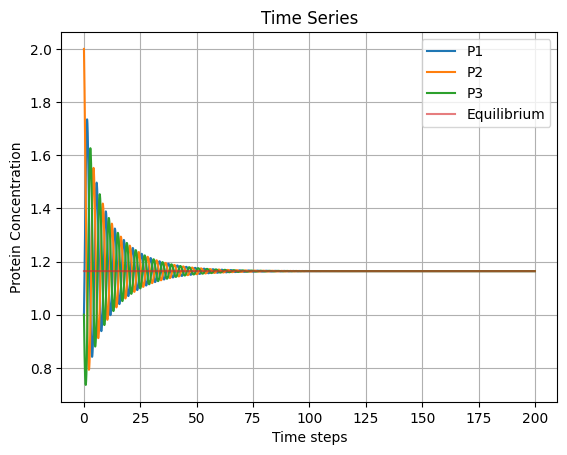

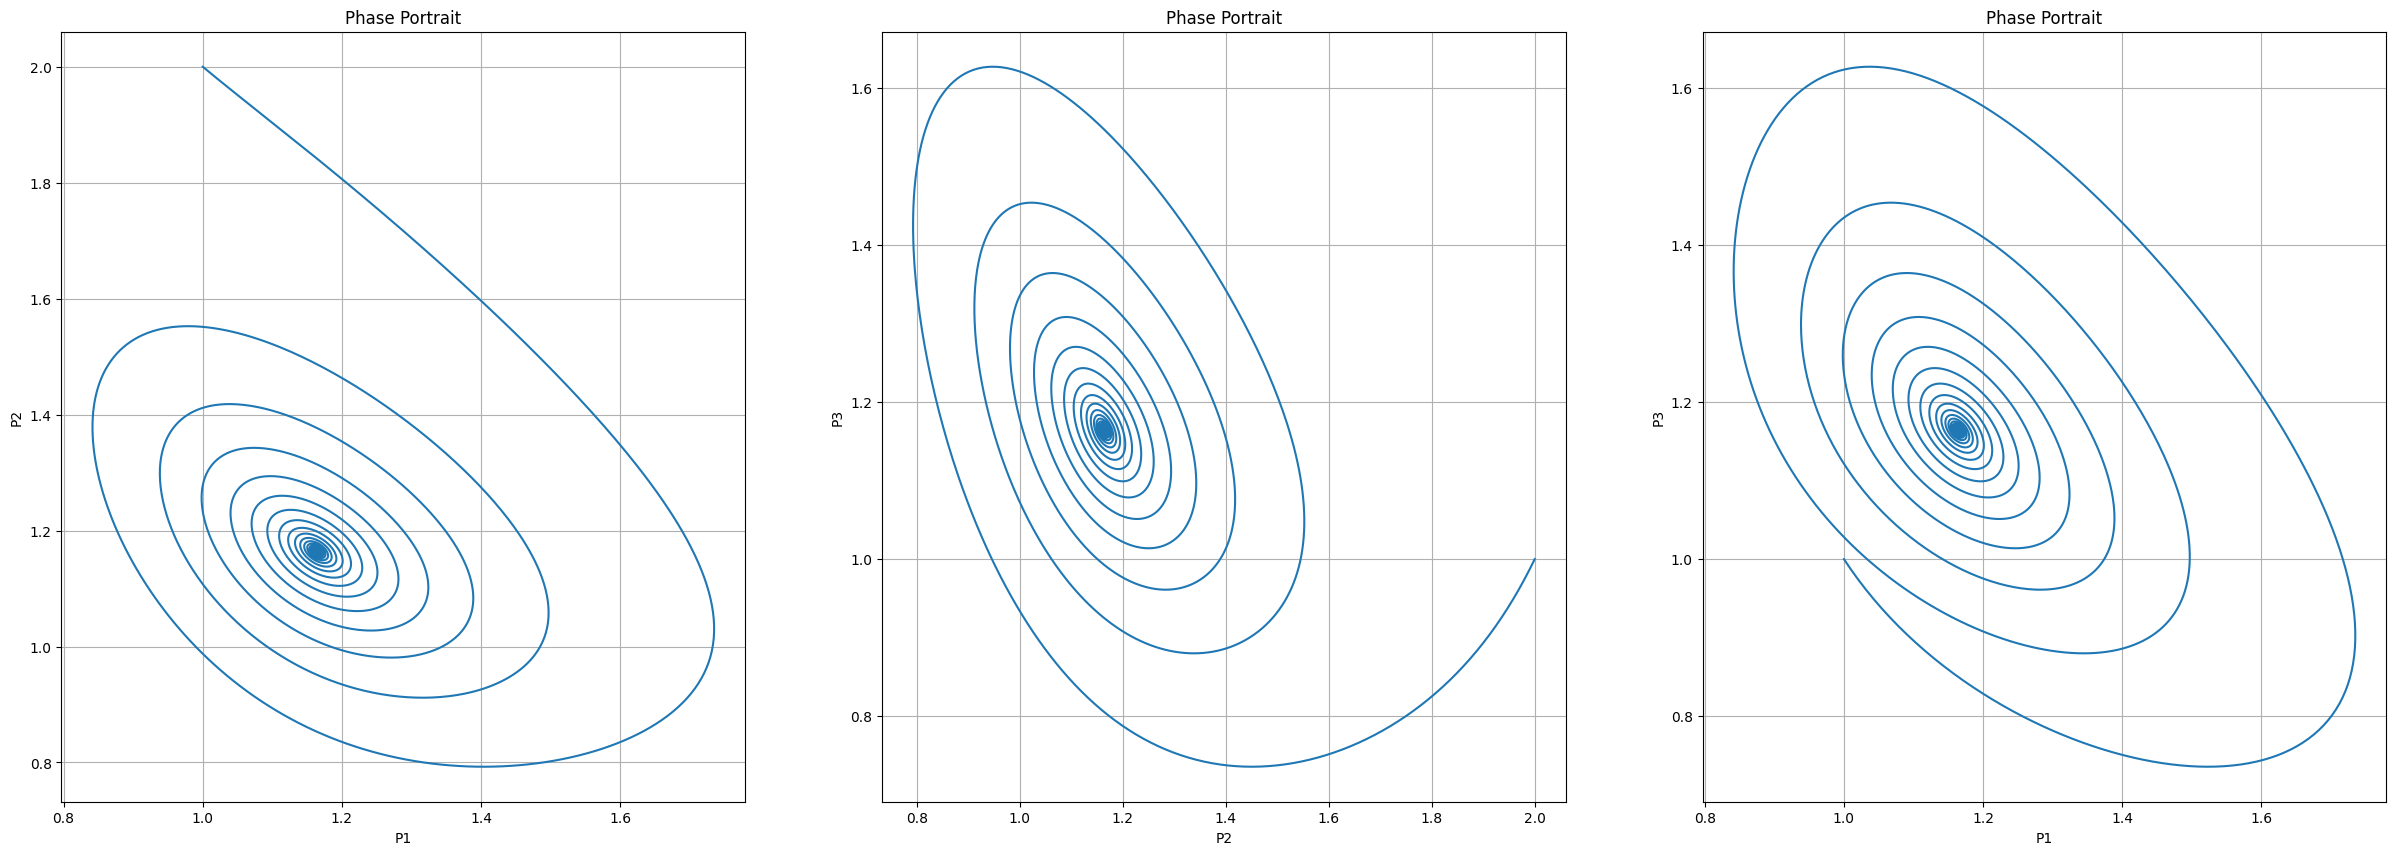

In [43]:
model = Repressilator(alpha = 3, gamma = 1, n = 3)
initial_state = np.array([1, 2, 1])
t, state, u, r, p_eq = model.simulate(initial_state)
time_series(t, state, p_eq)
phase_portrait(state)

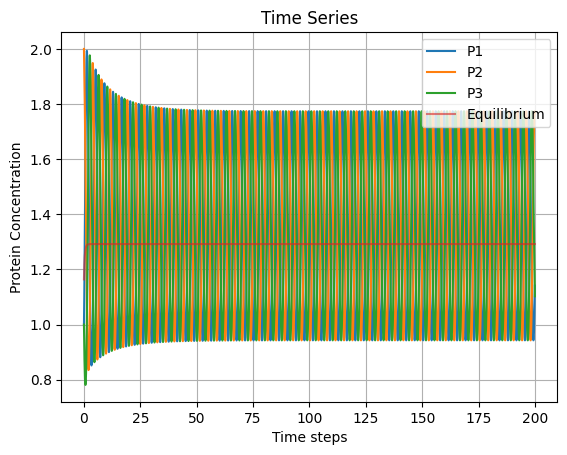

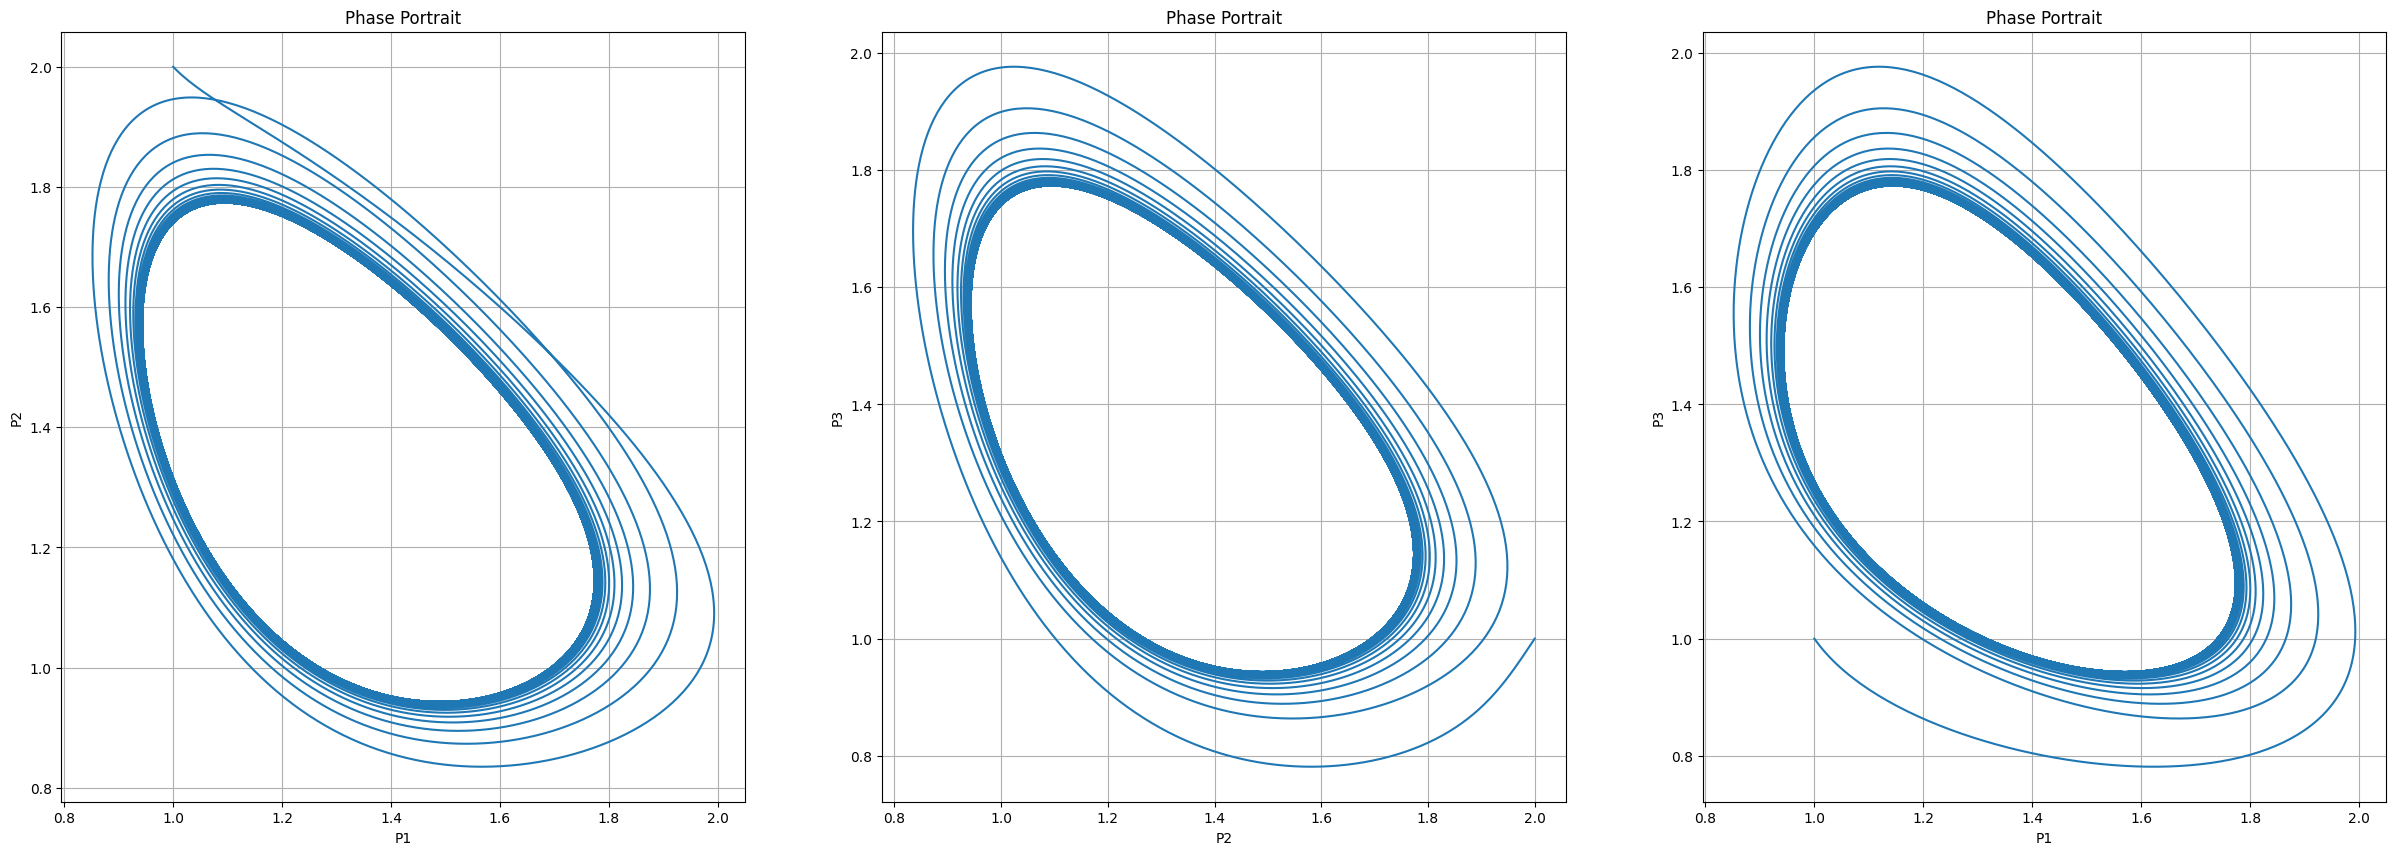

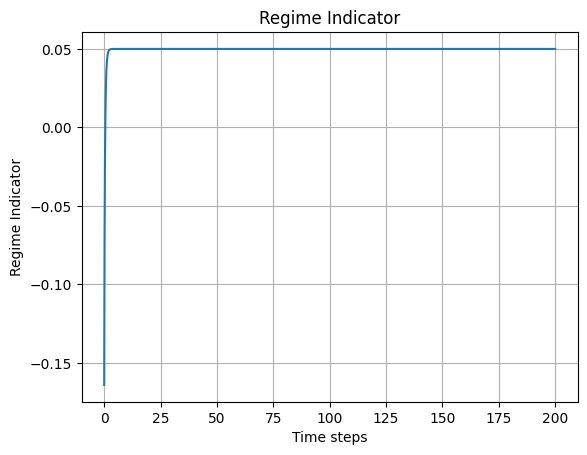

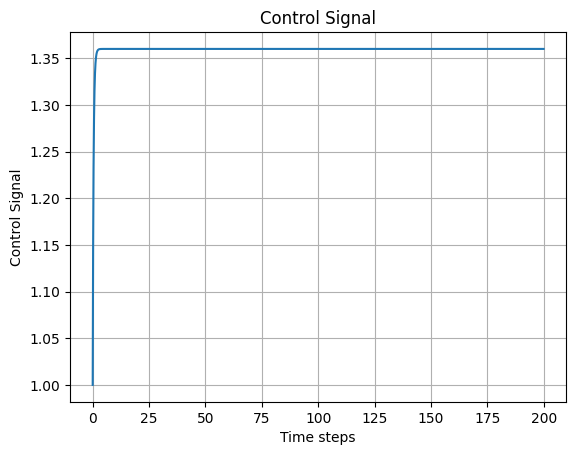

In [44]:
model = Repressilator(alpha = 3, gamma = 1, n = 3)
controller = PID(target_regime = 0.05)
t, state, u, r, p_eq = model.simulate(initial_state, control = controller, u0 = 1)
time_series(t, state, p_eq)
phase_portrait(state)
regime_indicator(t, r)
control_signal(t, u)

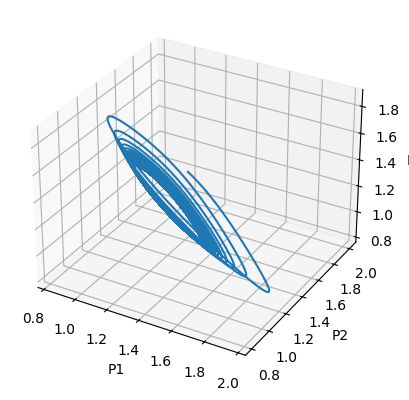

In [18]:
phase_portrait_3d(state)

100%|██████████| 10/10 [00:24<00:00,  2.43s/it]


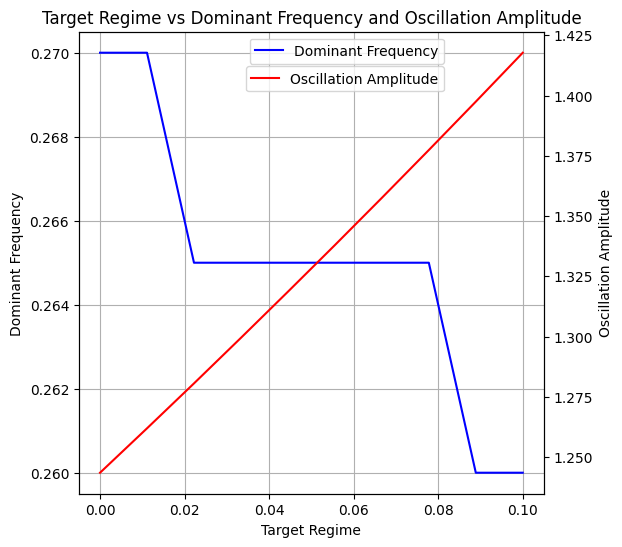

In [12]:
target_values = np.linspace(0, 0.1, 10)
dom_freqs = []
amps = []

for target in tqdm.tqdm(target_values):
    controller = PID(target_regime = target)
    t, state, u, r, p_eq = model.simulate(initial_state, control = controller, u0 = 1)
    dom_freq, freqs, spectrum = oscillation_freq(state[:,0], 0.01)
    amp = oscillation_amp(state[:,0])
    dom_freqs.append(dom_freq)
    amps.append(amp)

target_oscillation_plot(target_values, dom_freqs, amps)

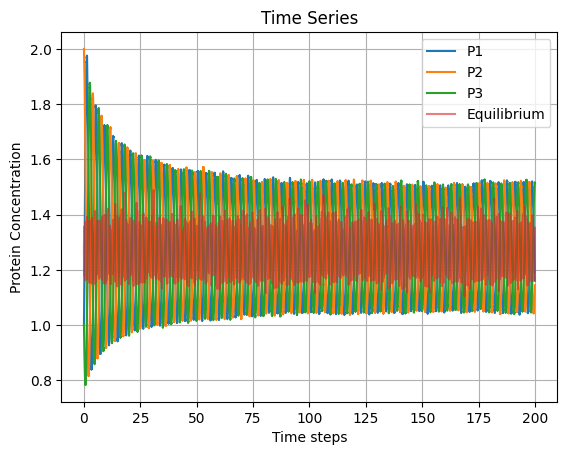

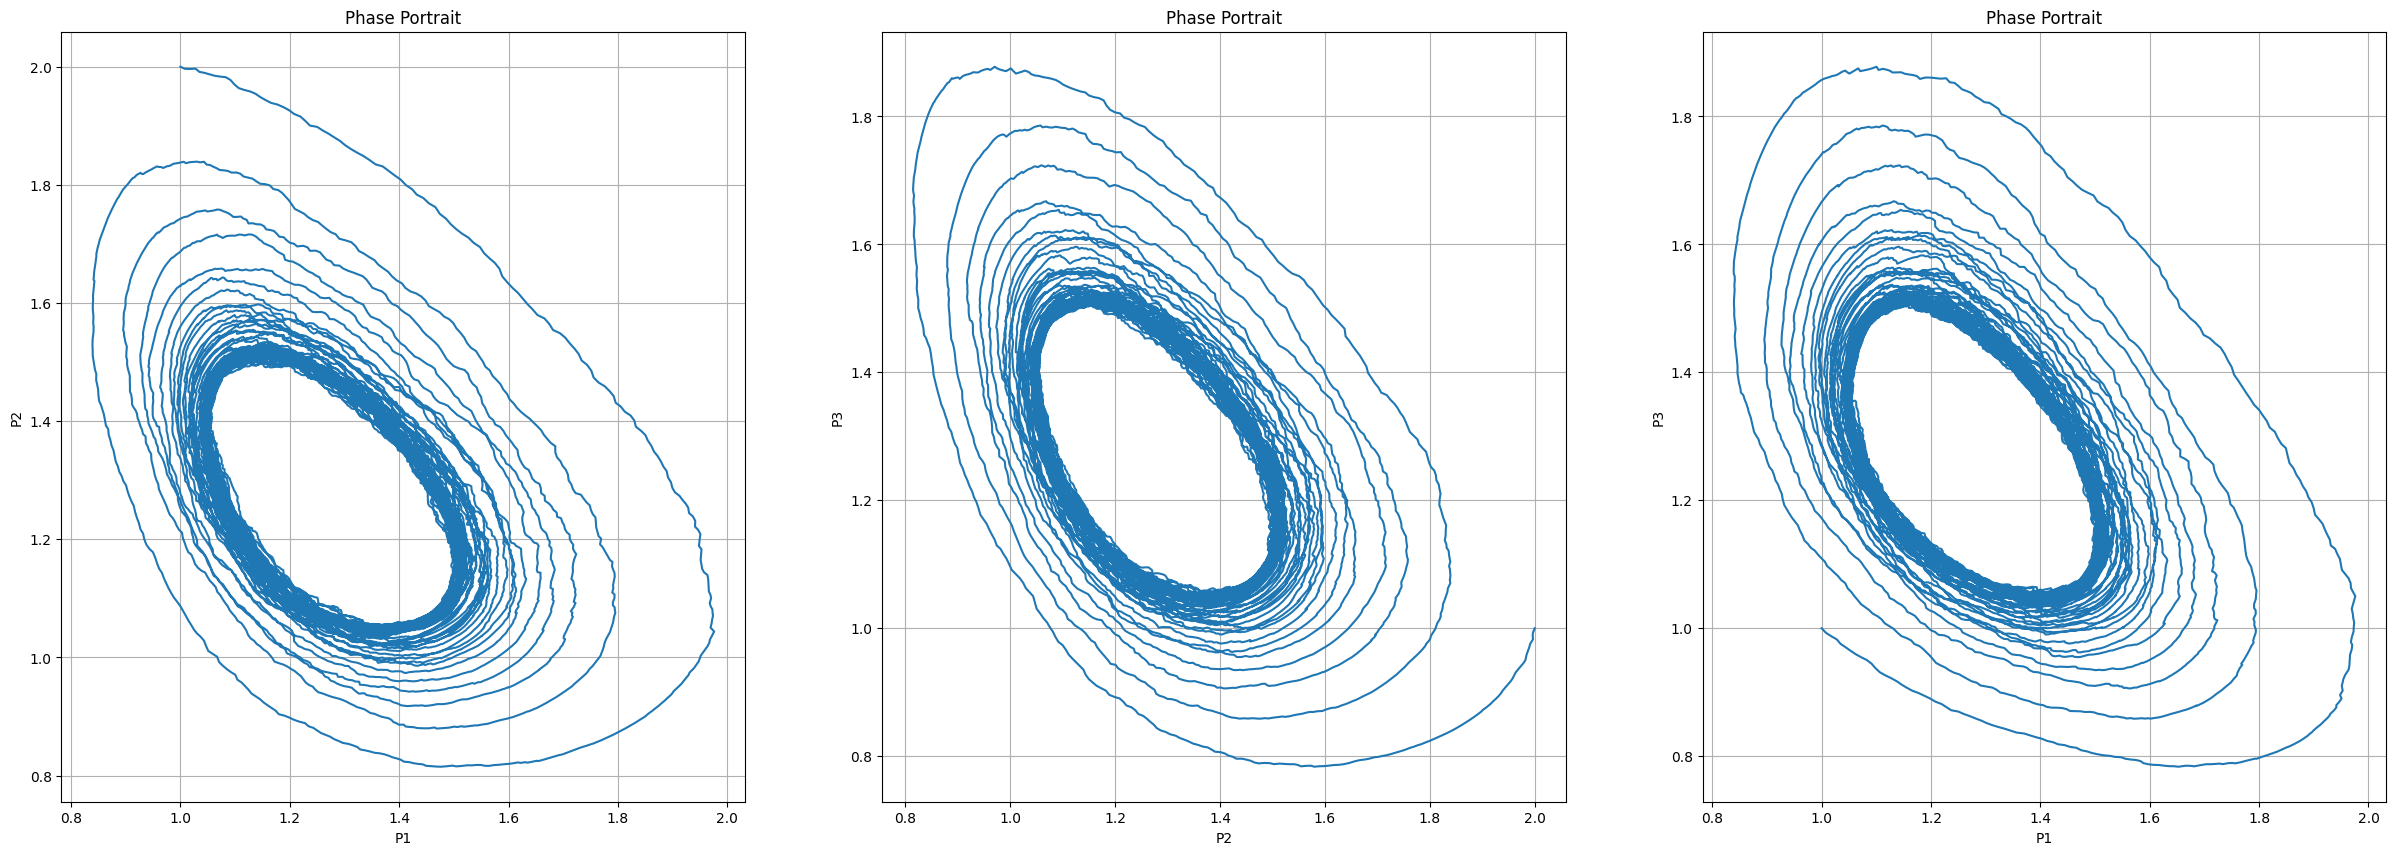

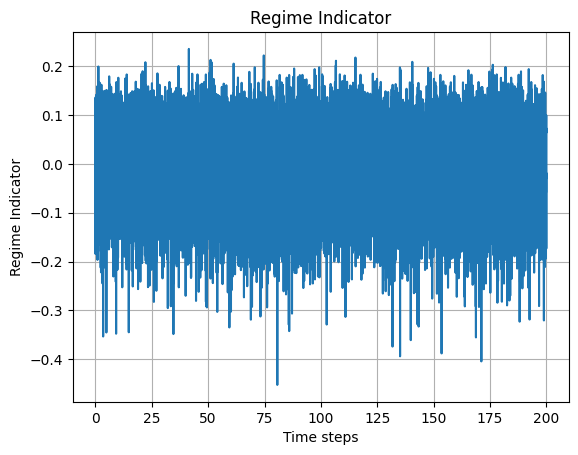

In [10]:
model = Repressilator(alpha = 3, gamma = 1, n = 3)
uc = fsolve(model.regime, 1)[0]
initial_state = np.array([1, 2, 1])
t, state, u, r, p_eq = model.noisy_simulate(initial_state, u0 = uc)
time_series(t, state, p_eq)
phase_portrait(state)
regime_indicator(t, r)

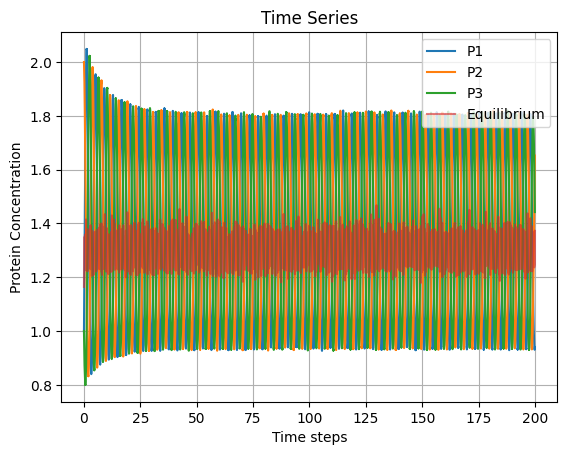

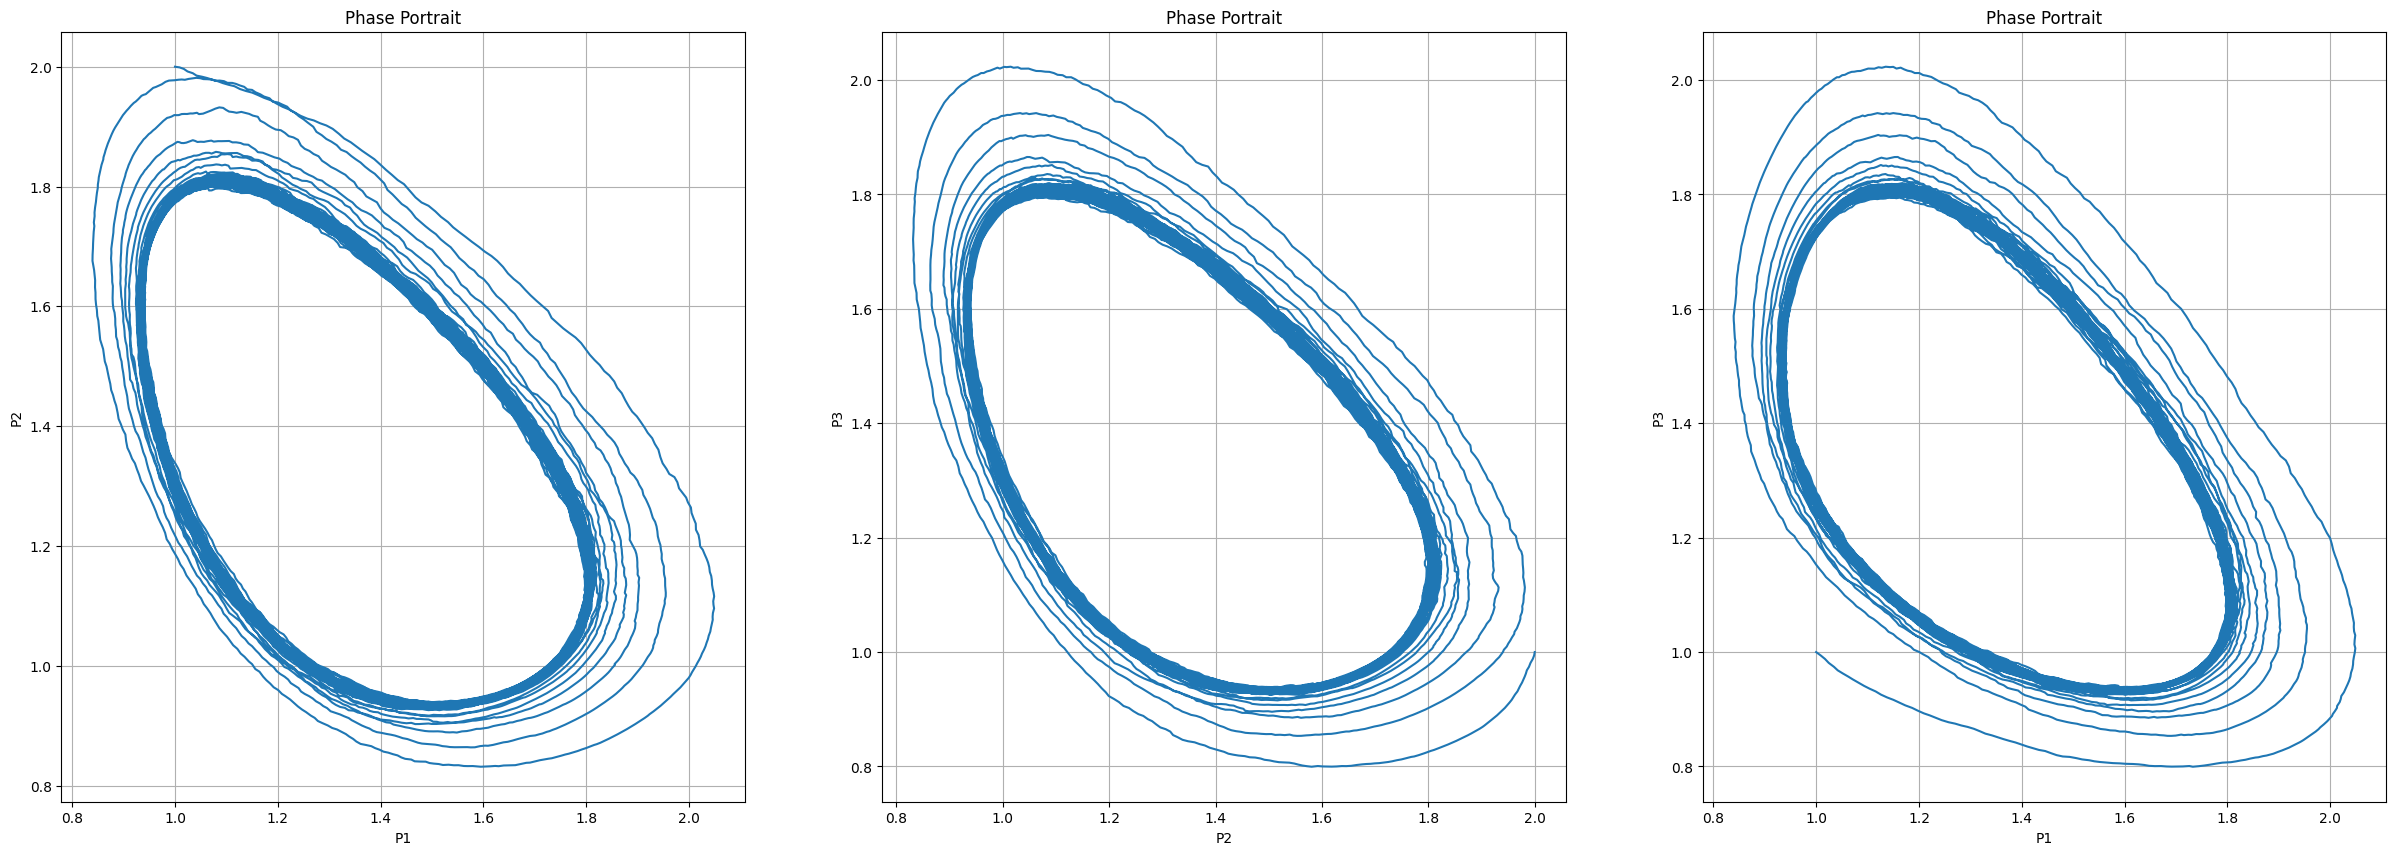

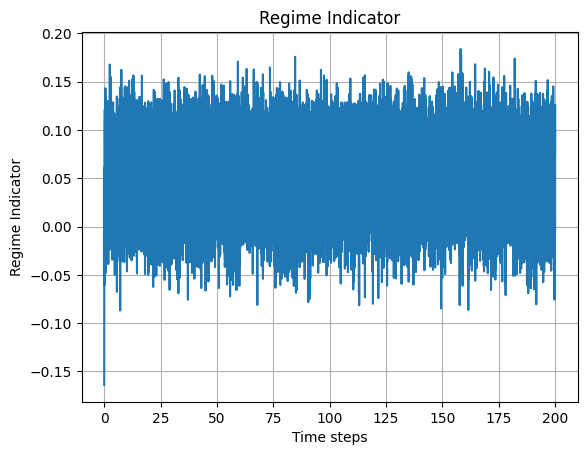

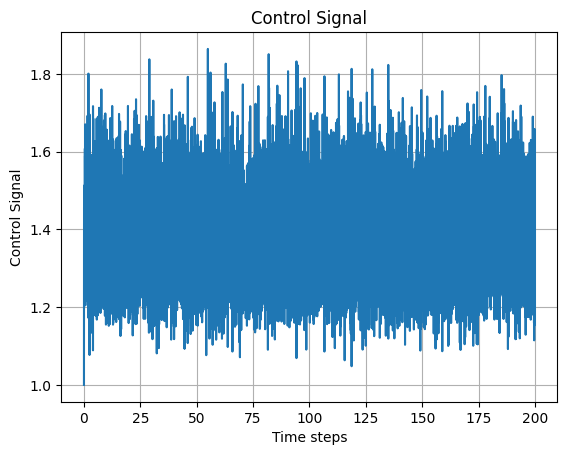

In [8]:
model = Repressilator(alpha = 3, gamma = 1, n = 3)
controller = PID(kp = 0.3, ki = 0.1, kd = 0.01, target_regime = 0.05)
initial_state = np.array([1, 2, 1])
t, state, u, r, p_eq = model.noisy_simulate(initial_state,control = controller, u0 = 1)
time_series(t, state, p_eq)
phase_portrait(state)
regime_indicator(t, r)
control_signal(t, u)